In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import european_analytics
from models import SABR
from scipy.stats import norm, lognorm
from matplotlib.lines import Line2D

In [3]:
# Model parameters 
F0=0.05
lambda_=0.04
F_s=F0+lambda_
T=1.0
beta=0.5
nu=0.3
rho=-0.3
sigma_atm= 0.01

# Simulation parameters
N_STEPS = 252
N_PATHS = 20_000
SEED    = 42

sabr = european_analytics.EuropeanAnalyticsSABR(F_s, T, beta, nu, rho, sigma_atm, lambda_)

print(f"alpha(inverted using Hagan formula): {sabr.alpha:.6f}")
print(f"F_shifted: {sabr.F_s:.4f}")

# Simulation
sim = SABR(
        F0=F_s, A0=sabr.alpha, rho=rho,
        T=T, n_steps=N_STEPS, 
        n_paths=N_PATHS, beta=beta, nu=nu, seed=SEED
    )
F_paths, A_paths = sim.run()
print(f"Paths shape: {F_paths.shape}")
print(f"Hagan implied vol: {sabr.hagan_implied_vol(F_s):.6f}")

alpha(inverted using Hagan formula): 0.033172
F_shifted: 0.0900
Paths shape: (20000, 253)
Hagan implied vol: 0.111168


Terminal F(T) — mean: 0.04994  std: 0.01019  skew: -0.100  kurt: 0.394


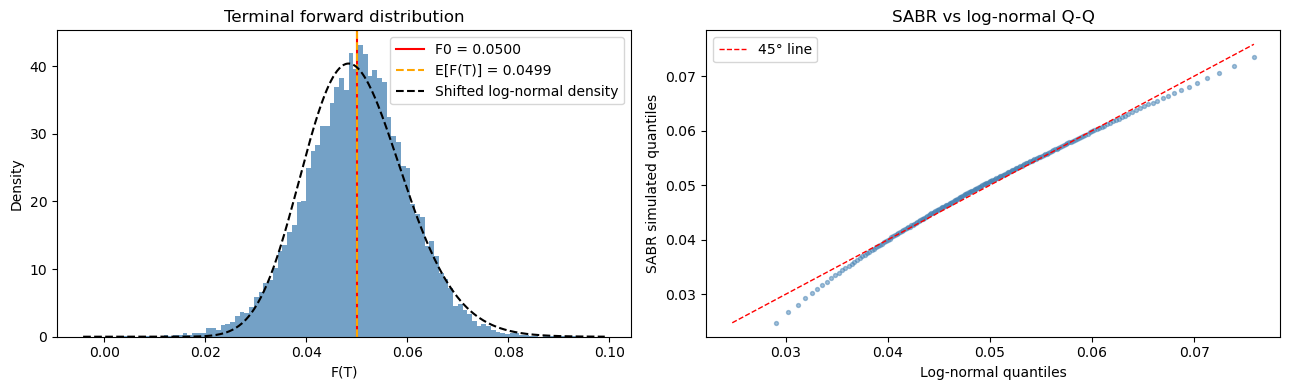

In [4]:
# Simulation runs in shifted space; convert terminal values back to original forward space
F_T_shifted = F_paths[:, -1]
F_T = F_T_shifted - lambda_            # terminal forward, original space
F0  = F_s - lambda_                    # original (unshifted) forward

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram of F(T) in original space ---
axes[0].hist(F_T, bins=100, color='steelblue', alpha=0.75, density=True)
axes[0].axvline(F0, color='red', lw=1.5, label=f'F0 = {F0:.4f}')
axes[0].axvline(np.mean(F_T), color='orange', lw=1.5, linestyle='--',
                label=f'E[F(T)] = {np.mean(F_T):.4f}')

# Log-normal reference lives in SHIFTED space, so evaluate the pdf at (x + shift).
# The transform F = F_shifted - shift is a pure translation (Jacobian = 1),
# so no density rescaling is needed — just shift the argument.
mu_ln    = np.log(F_s) - 0.5 * sabr.sigma_ln_atm**2 * T
sigma_ln = sabr.sigma_ln_atm * np.sqrt(T)
x_min, x_max = axes[0].get_xlim()
x_grid = np.linspace(x_min, x_max, 500)
ln_pdf = lognorm.pdf(x_grid + lambda_, s=sigma_ln, scale=np.exp(mu_ln))

axes[0].plot(x_grid, ln_pdf, 'k--', lw=1.5, label='Shifted log-normal density')
axes[0].set_xlabel('F(T)')
axes[0].set_ylabel('Density')
axes[0].set_title('Terminal forward distribution')
axes[0].legend()

# --- QQ plot in original space ---
probs = np.linspace(1, 99, 200)
q_sim = np.percentile(F_T, probs)
z     = norm.ppf(probs / 100.0)
# log-normal quantiles computed in shifted space, then shifted back
q_ln  = F_s * np.exp(-0.5 * sabr.sigma_ln_atm**2 * T
                     + sabr.sigma_ln_atm * np.sqrt(T) * z) - lambda_

axes[1].scatter(q_ln, q_sim, s=8, alpha=0.5, color='steelblue')
mn, mx = min(q_ln.min(), q_sim.min()), max(q_ln.max(), q_sim.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1, label='45° line')
axes[1].set_xlabel('Log-normal quantiles')
axes[1].set_ylabel('SABR simulated quantiles')
axes[1].set_title('SABR vs log-normal Q-Q')
axes[1].legend()

# Stats in original space (skew/kurt/std are translation-invariant; only mean shifts)
stats = sim.compute_stats(F_paths - lambda_)
print(f"Terminal F(T) — mean: {stats['mean'][-1]:.5f}  "
      f"std: {stats['std_dev'][-1]:.5f}  "
      f"skew: {stats['skewness'][-1]:.3f}  "
      f"kurt: {stats['kurtosis'][-1]:.3f}")
plt.tight_layout()
plt.show()

Comparing our simulated F(T) distribution to a pure log-normal benchmark (same F_s, sigma_atm, T), 
both the histogram and Q-Q plot show a slight negative skew: a fatter left tail and a thinner right 
tail relative to log-normal. This comes from the combination of rho and nu in the SABR dynamics.

Nu is the vol-of-vol — it's zero by construction in the log-normal benchmark, but in our simulation 
it's small and positive. This lets the volatility (alpha) itself wander away from its starting level, 
which makes extreme moves in F more likely on both sides, fattening both tails symmetrically.

Rho is what breaks the symmetry. With rho negative, falls in F tend to coincide with rises in alpha, 
and rises in F tend to coincide with falls in alpha. So when F is already low, vol tends to be 
higher, making further extreme drops more likely — fattening the left tail. When F is high, vol 
tends to be lower, making further extreme rallies less likely — thinning the right tail.

Since nu is small here, its symmetric tail-fattening effect is less pronouned, so rho's asymmetric effect 
dominates and the net result is the negative skew we see: fat left, thin right.

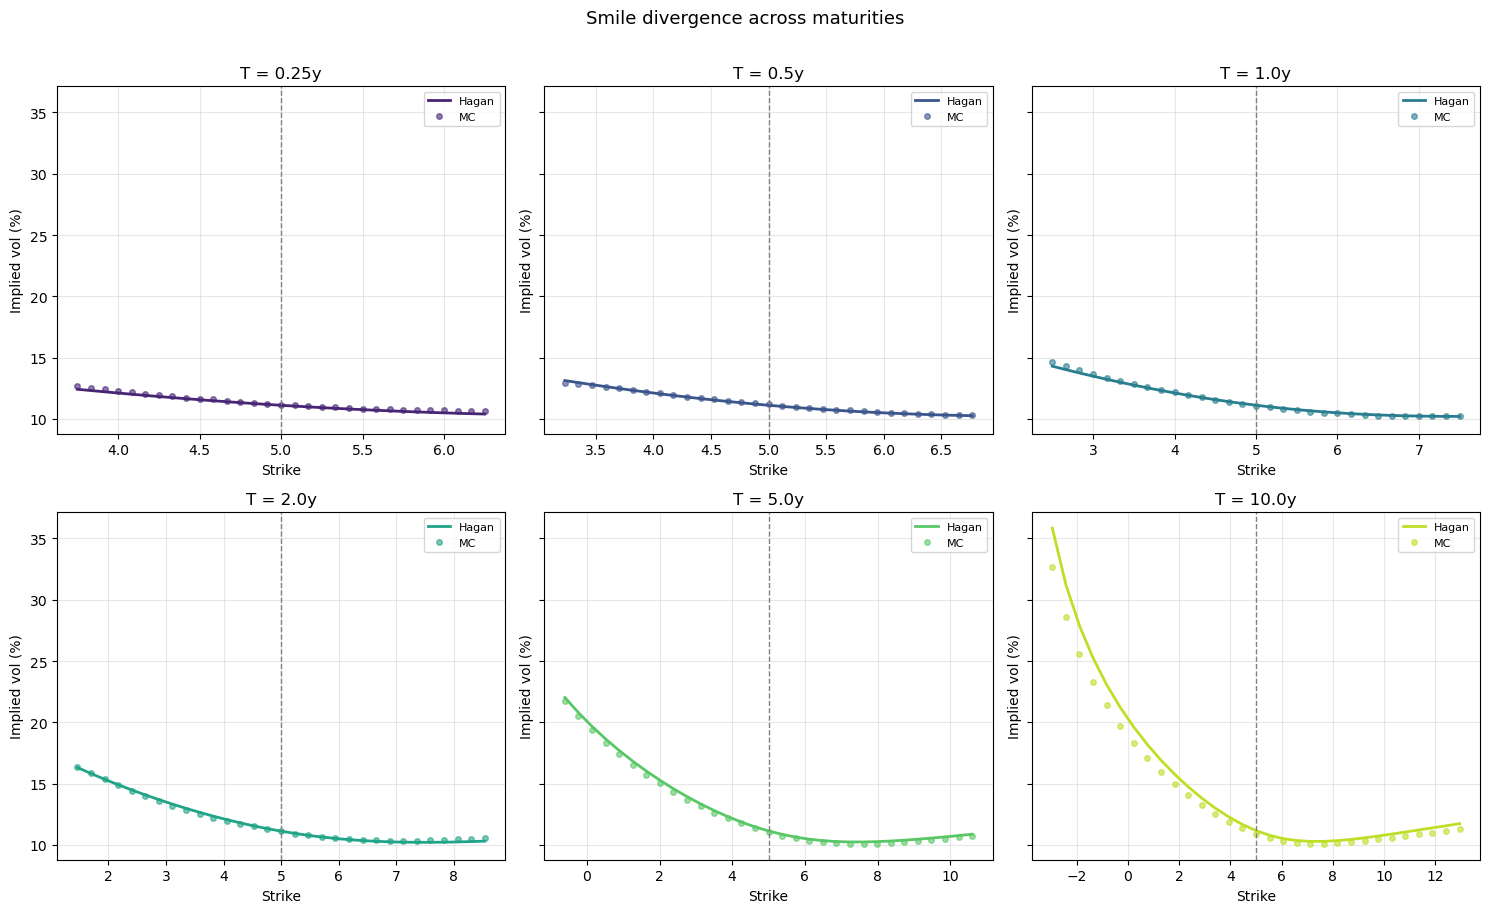

In [5]:
# Sweep over maturities to analyse how the Hagan approximation degrades with time to expiry
maturities = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

# For different colours in the plots
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(maturities)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, T_i, col in zip(axes, maturities, colors):
    # Calibrate alpha from sigma_atm and store SABR analytics maturity T_i
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_i, beta, nu, rho, sigma_atm, lambda_)

    # Initialise simulator in shifted space F_s so the forward stays positive
    sim_i = SABR(
        F0=F_s, A0=sabr_i.alpha, rho=rho,
        T=T_i, n_steps=max(int(2000 * T_i), 200),
        n_paths=N_PATHS, beta=beta, nu=nu, seed=SEED
    )
    # Run the simulation
    F_s_paths, _ = sim_i.run()
    # Terminal values (kept in shifted space for MC pricing)
    F_s_T = F_s_paths[:, -1]

    # Strike grid centered on F_s (shifted space), spanning ±2.5 std
    sigma_atm_ln = sabr_i.sigma_ln_atm
    std_i = sigma_atm_ln * F_s * np.sqrt(T_i)
    strikes_i = np.linspace(F_s - 2.5 * std_i, F_s + 2.5 * std_i, 31)

    # Vols are computed on SHIFTED strikes — do NOT change these calls
    v_hagan = sabr_i.implied_vol_smile(strikes_i)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, strikes_i)

    # Only the DISPLAY axis moves back to original forward space
    strikes_i_orig = strikes_i - lambda_
    F0 = F_s - lambda_

    # Plots
    ax.plot(strikes_i_orig * 100, v_hagan * 100, color=col, lw=2, label='Hagan')
    ax.plot(strikes_i_orig * 100, v_mc * 100, 'o', color=col, ms=4, alpha=0.6, label='MC')
    ax.axvline(F0 * 100, color='gray', lw=1, ls='--')
    ax.set_title(f'T = {T_i}y')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied vol (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Smile divergence across maturities', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## IV Smile Analysis ($T$ Sweep)

**Experiment:** Fix $\beta$ = 0.5, $\nu$ = 0.3, $\rho$ = -0.3 and sweep $T$ across 
[0.25, 0.5, 1.0, 2.0, 5.0, 10.0] years, comparing Hagan's semi-analytic smile against MC 
at each maturity.

**Results:** As $T$ increases, the smile becomes more pronounced since $F$ has more time to 
diffuse, and with $\nu$ pushing the vol process around, the terminal distribution of $F$ gets 
wider and more skewed away from log-normal. This shows up as a steeper, more curved implied 
vol curve across strikes, which matches what we already saw in the histogram and Q-Q plot for 
the terminal distribution.

At the same time, Hagan's approximation increasingly diverges from MC as $T$ grows, and the 
divergence is worst at the wings rather than near the money. At short maturities ($T$ = 0.25, 
0.5), Hagan tracks MC closely across the full strike range. By $T$ = 5.0 and $T$ = 10.0, the 
gap becomes wider, and Hagan's curve now overstimates the actual IV curve. 

**Takeaway:** Hagan's formula is only accurate when the cumulative vol-of-vol effect (roughly $\nu^2 T$) stays small. As $T$ increases, this quantity grows, so the higher-order terms the expansion drops become significant and the approximation 
breaks down. The wings are affected more because they depend on the tail behavior of $F$, which is exactly where the true SABR distribution deviates most from the log-normal-like assumption underlying Hagan's expansion, the same tail deviation we already identified in the Q-Q plot and histogram analysis.

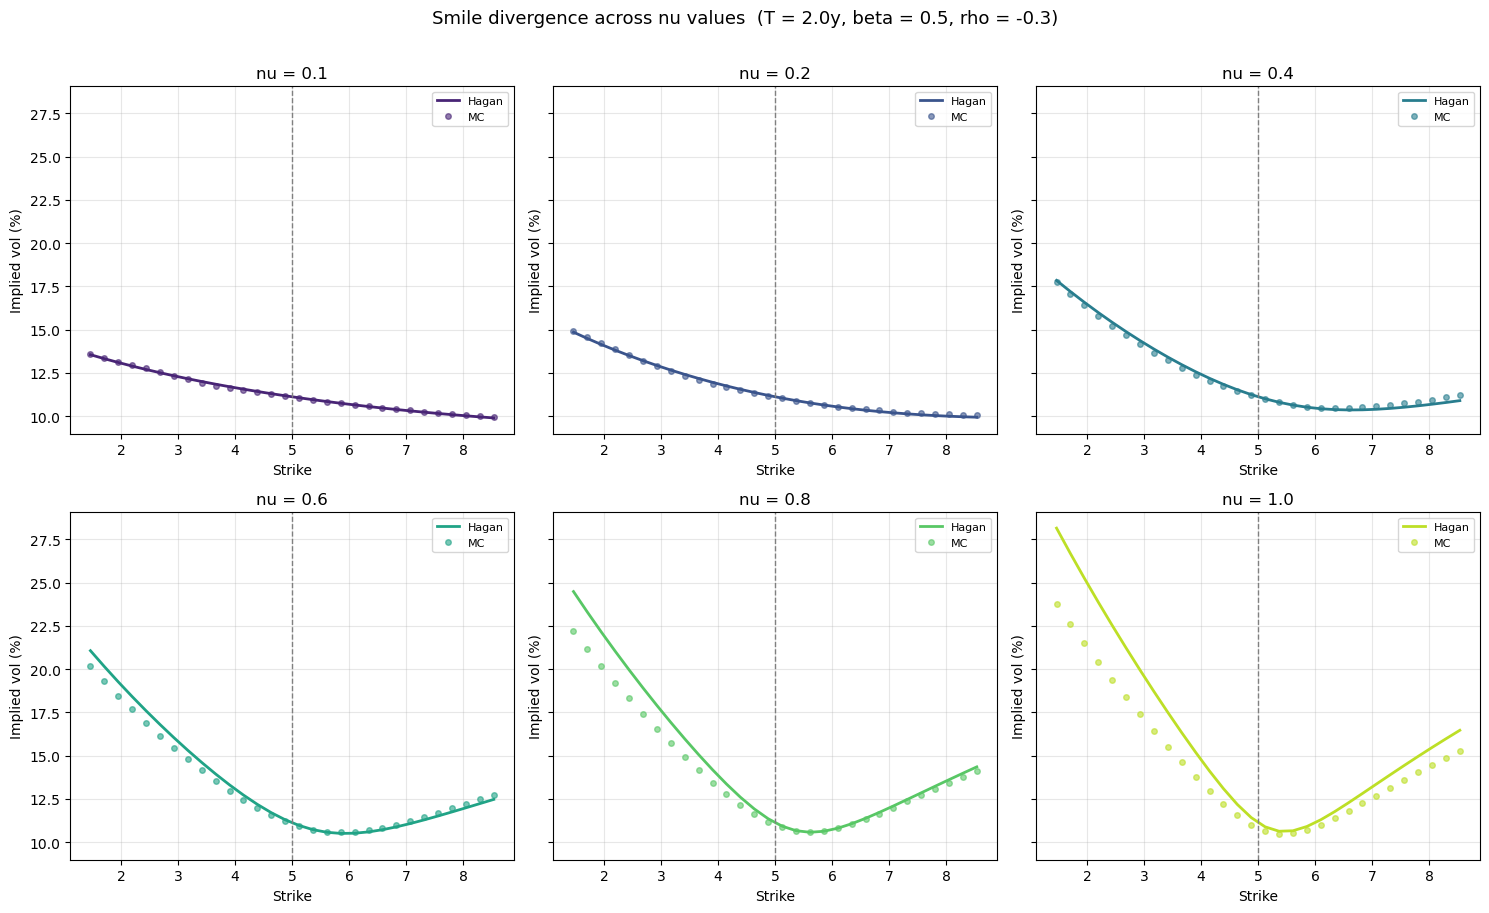

In [6]:
# nu sweep
# Fix maturity and all other params; vary vol-of-vol
# expect to see amplification of the divergence between Hagan's approximation and MC

nu_values = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.0])

colors_nu = plt.cm.viridis(np.linspace(0.1, 0.9, len(nu_values)))

T_fixed = 2.0

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, nu_i, col in zip(axes, nu_values, colors_nu):
    # Calibrate alpha from sigma_atm
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_fixed, beta, nu_i, rho, sigma_atm, lambda_)

    # SABR subclass implicitly handles simulations
    sim_i = SABR(
        F0=F_s, A0=sabr_i.alpha, rho=rho,
        T=T_fixed, n_steps=max(int(2000 * T_fixed), 200),
        n_paths=N_PATHS, beta=beta, nu=nu_i, seed=SEED
    )
    # returns (n_paths x n_steps+1) arrays
    F_s_paths, _ = sim_i.run()
    # Terminal values across all paths (shifted space, kept for MC pricing)
    F_s_T = F_s_paths[:, -1]

    # Strike grid centered on F_s (shifted space), spanning ±2.5 std
    sigma_atm_ln = sabr_i.sigma_ln_atm
    std_i = sigma_atm_ln * F_s * np.sqrt(T_fixed)
    K_grid = np.linspace(F_s - 2.5 * std_i, F_s + 2.5 * std_i, 30)

    # Vols computed on SHIFTED strikes — do NOT change these calls
    v_hagan = sabr_i.implied_vol_smile(K_grid)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, K_grid)

    # Only the DISPLAY axis moves back to original forward space
    K_grid_orig = K_grid - lambda_
    F0 = F_s - lambda_

    # Plot both smiles
    ax.plot(K_grid_orig * 100, v_hagan * 100, color=col, lw=2, label='Hagan')
    ax.plot(K_grid_orig * 100, v_mc * 100, 'o', color=col, ms=4, alpha=0.6, label='MC')
    ax.axvline(F0 * 100, color='gray', lw=1, ls='--')
    ax.set_title(f'nu = {nu_i}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied vol (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f'Smile divergence across nu values  (T = {T_fixed}y, beta = {beta}, rho = {rho})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## IV smile analysis($\nu$ sweep)
**Experiment.** We fix $T = 2\text{y}$, $\beta = 0.5$, $\rho = -0.3$ and sweep the vol-of-vol
$\nu \in \{0.1, 0.2, 0.4, 0.6, 0.8, 1.0\}$, comparing Hagan's semi-analytic smile against the
Monte Carlo smile (OTM options, inverted against the empirical forward $\bar{F}$).

**Results.** As $\nu$ increases, the smile deepens: its curvature grows and both wings rise
relative to ATM. At low $\nu$ (0.1, 0.2) Hagan and MC agree closely across all strikes. As $\nu$
increases to 0.8–1.0 the two curves separate, with the discrepancy concentrated in the wings and
noticeably larger on the OTM-put (low-strike) side than the OTM-call (high-strike) side.

**Takeaway.** $\nu$ controls the overall smile steepening through symmetric tail-fattening, while
$\rho < 0$ tilts that curvature toward the downside. The combination makes the OTM-put wing both the
most curved region and the region where Hagan's approximation breaks down first as $\nu$ grows.

<bound method Axes.set of <Axes: >>

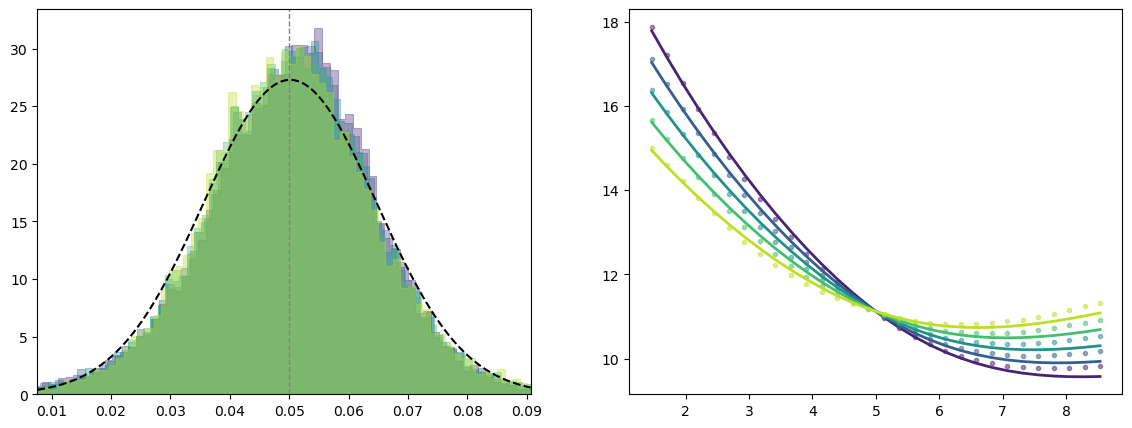

In [7]:
# 1. Beta Sweep
# vary beta from 0 (normal) to 1 (log-normal), show distribution and smile together

beta_values  = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
colors_beta  = plt.cm.viridis(np.linspace(0.1, 0.9, len(beta_values)))
all_F_T_beta = []   # store ORIGINAL-space terminal values for the distribution panel

F0 = F_s - lambda_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for beta_i, col in zip(beta_values, colors_beta):
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_fixed, beta_i, nu, rho, sigma_atm, lambda_)
    sim_i  = SABR(F0=F_s, A0=sabr_i.alpha, rho=rho,
                  T=T_fixed, n_steps=max(int(2000 * T_fixed), 200),
                  n_paths=N_PATHS, beta=beta_i, nu=nu, seed=SEED)
    F_s_paths, _ = sim_i.run()
    F_s_T = F_s_paths[:, -1]              # shifted space — used for MC pricing
    F_T   = F_s_T - lambda_               # original space — used for the histogram
    all_F_T_beta.append(F_T)

    std_i  = sigma_atm * np.sqrt(T_fixed)
    K_grid = np.linspace(F_s - 2.5 * std_i, F_s + 2.5 * std_i, 30)   # shifted strikes

    # Vols computed on SHIFTED strikes and SHIFTED samples — do NOT change
    v_hagan = sabr_i.implied_vol_smile(K_grid)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, K_grid)

    K_grid_orig = K_grid - lambda_       # display strikes in original space

    axes[0].hist(F_T, bins=120, density=True, alpha=0.35, color=col,
                 histtype='stepfilled', edgecolor=col, linewidth=0.8, label=f'beta={beta_i}')
    axes[1].plot(K_grid_orig * 100, v_hagan * 100, color=col, lw=2, label=f'beta={beta_i} Hagan')
    axes[1].plot(K_grid_orig * 100, v_mc    * 100, 'o', color=col, ms=3, alpha=0.5)

# normal reference fitted to beta=0, all in ORIGINAL space
lo, hi = np.percentile(np.concatenate(all_F_T_beta), [0.5, 99.5])
axes[0].set_xlim(lo, hi)
x_ref = np.linspace(lo, hi, 300)
mu_ref, std_ref = norm.fit(all_F_T_beta[0])
axes[0].plot(x_ref, norm.pdf(x_ref, mu_ref, std_ref),
             color='black', lw=1.5, ls='--', label='Normal ref')

axes[0].axvline(F0, color='gray', lw=1, ls='--')
axes[0].set

## Terminal Distribution of $F_T$ and IV smile analysis($\beta$ sweep)

**Experiment:** Fix $T = 2y$ and sweep $\beta$ parameter from 0 to 1 to isolate its effect on the terminal distribution of the forward rate $F_T$.

For the IV curve, we see that purple is the steepest smile(beta=0) and green is the flattest(beta=1) why?

**Terminal distribution:** $\beta$ controls the normal vs lognormal dynamics of F. At $\beta$=0, F follows arithmetic dynamics (normal SABR), while at $\beta$=1 it follows geometric dynamics (lognormal SABR). Since lognormal has positive skew (fat right tail, thin left tail), higher $\beta$ distributions lean slightly more rightward. However, with $\rho$=-0.3 simultaneously 
introducing negative skew, the two effects partially cancel, which is why the histograms look broadly similar across all $\beta$ values and are hard to distinguish visually.

**IV smile:** All curves are calibrated to the same ATM vol (~11%), so the differences across $\beta$ are entirely in the wings.

On the OTM puts side (left wing, low strikes), $\beta = 0$ is the highest and $\beta = 1$ is the lowest, 
and the smile steepens as $\beta$ decreases. At low $\beta$, the local vol term $F^\beta$ is weak 
and hence the majority of the smile shape comes from $\rho$ and $\nu$. As $\beta$ increases, the 
model behaves more lognormally, which gives it thinner left tails and as a result a flatter IV curve 
on the left wing. The higher curvature of the IV curve for $\beta = 0$ directly reflects higher 
probability density of $F_T$ in the left tail region, also by Breeden-Litzenberger, the risk neutral 
density of $F_T$ at a given strike is the second derivative of the call price with respect to $K$.

On the OTM calls side (right wing, high strikes), the ordering flips. $\beta = 1$ is the highest and 
$\beta = 0$ is now the lowest. This is because lognormal distributions have positive skew, meaning fatter 
right tails, so there is higher probability of $F_T$ ending up above high strikes when the underlying 
follows lognormal dynamics compared to normal. This higher right-tail mass prices into higher implied 
volatility at OTM strikes for larger $\beta$.

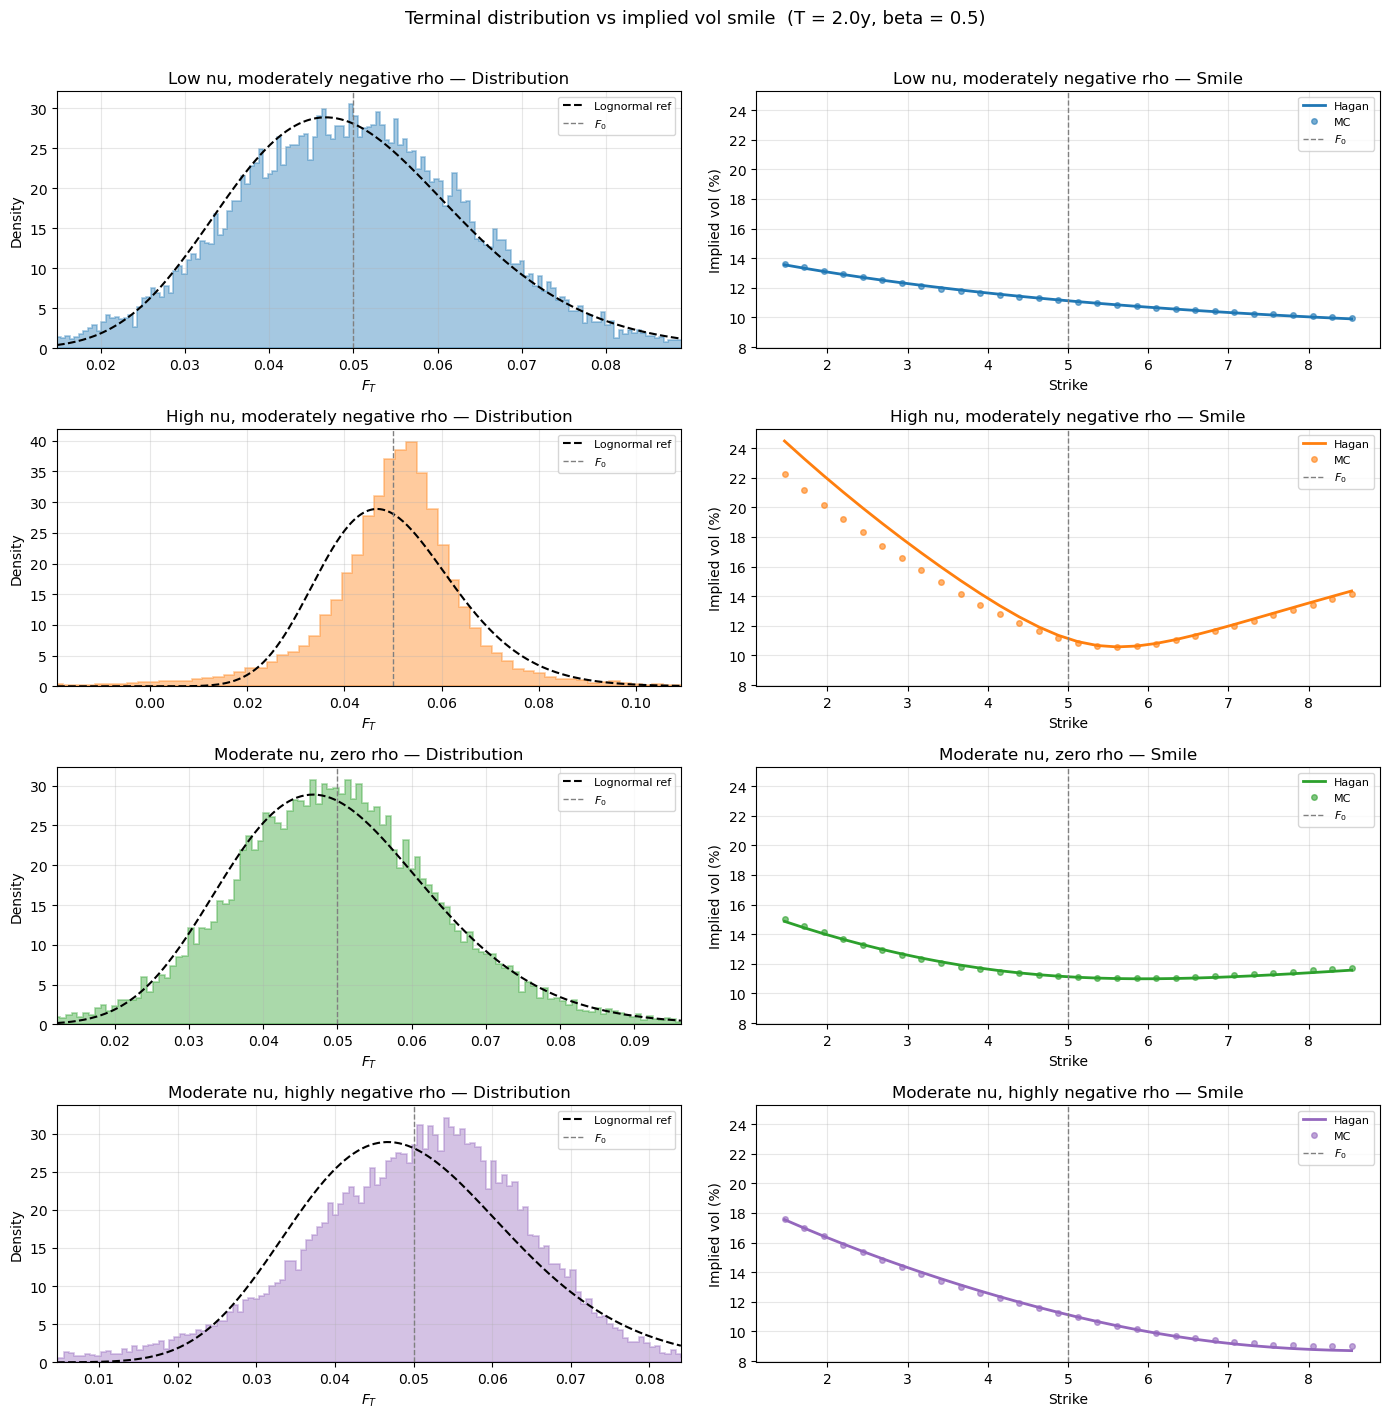

In [8]:
# Link Distribution to Smile
# terminal distribution of F_T next to the implied vol smile
# shows how fat tails / skew in the distribution map to the smile

params_to_plot = [
    {'nu': 0.1, 'rho': -0.3, 'label': 'Low nu, moderately negative rho'},
    {'nu': 0.8, 'rho': -0.3, 'label': 'High nu, moderately negative rho'},
    {'nu': 0.3, 'rho':  0.0, 'label': 'Moderate nu, zero rho'},
    {'nu': 0.3, 'rho': -0.6, 'label': 'Moderate nu, highly negative rho'},
]

colors_cases = plt.cm.tab10(np.linspace(0, 0.4, len(params_to_plot)))

F0 = F_s - lambda_

fig, axes = plt.subplots(len(params_to_plot), 2, figsize=(14, 14))
for r in range(1, len(params_to_plot)):
    axes[r, 1].sharey(axes[0, 1])

for i, (params, col) in enumerate(zip(params_to_plot, colors_cases)):
    nu_i  = params['nu']
    rho_i = params['rho']

    # Calibrate alpha from sigma_atm for this (nu_i, rho_i) pair
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_fixed, beta, nu_i, rho_i, sigma_atm, lambda_)

    # SABR subclass handles simulation; base class run() vectorizes path generation
    sim_i = SABR(
        F0=F_s, A0=sabr_i.alpha, rho=rho_i,
        T=T_fixed, n_steps=max(int(2000 * T_fixed), 200),
        n_paths=N_PATHS, beta=beta, nu=nu_i, seed=SEED
    )
    # returns (n_paths x n_steps+1)
    F_s_paths, _ = sim_i.run()
    F_s_T = F_s_paths[:, -1]          # shifted space — used for MC pricing
    F_T   = F_s_T - lambda_           # original space — used for the histogram

    # Strike grid (shifted space)
    std_i  = sigma_atm * np.sqrt(T_fixed)
    K_grid = np.linspace(F_s - 2.5 * std_i, F_s + 2.5 * std_i, 30)

    # Vols computed on SHIFTED strikes and SHIFTED samples — do NOT change
    v_hagan = sabr_i.implied_vol_smile(K_grid)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, K_grid)

    K_grid_orig = K_grid - lambda_   # display strikes in original space

    # Left side - terminal distribution (original space)
    ax_dist = axes[i, 0]
    ax_dist.hist(F_T, bins=200, density=True, alpha=0.4, color=col,
                 histtype='stepfilled', edgecolor=col, linewidth=1.2)

    # Lognormal reference lives in SHIFTED space: evaluate pdf at (x + lambda_)
    mu_ln    = np.log(F_s) - 0.5 * sabr_i.sigma_ln_atm**2 * T_fixed
    sigma_ln = sabr_i.sigma_ln_atm * np.sqrt(T_fixed)
    lo, hi = np.percentile(F_T, [0.5, 99.5])
    x_ref = np.linspace(lo, hi, 300)
    ax_dist.plot(x_ref, lognorm.pdf(x_ref + lambda_, s=sigma_ln, scale=np.exp(mu_ln)),
                 'k--', lw=1.5, label='Lognormal ref')

    ax_dist.axvline(F0, color='gray', lw=1, ls='--', label='$F_0$')
    ax_dist.set_xlim(lo, hi)
    ax_dist.set_title(f'{params["label"]} — Distribution')
    ax_dist.set_xlabel(r'$F_T$')
    ax_dist.set_ylabel('Density')
    ax_dist.legend(fontsize=8)
    ax_dist.grid(alpha=0.3)

    # Right side - implied vol smile
    ax_smile = axes[i, 1]
    ax_smile.plot(K_grid_orig * 100, v_hagan * 100, color=col, lw=2,    label='Hagan')
    ax_smile.plot(K_grid_orig * 100, v_mc    * 100, 'o', color=col, ms=4,
                  alpha=0.6, label='MC')
    ax_smile.axvline(F0 * 100, color='gray', lw=1, ls='--', label='$F_0$')
    ax_smile.set_title(f'{params["label"]} — Smile')
    ax_smile.set_xlabel('Strike')
    ax_smile.set_ylabel('Implied vol (%)')
    ax_smile.legend(fontsize=8)
    ax_smile.grid(alpha=0.3)

fig.suptitle(f'Terminal distribution vs implied vol smile  (T = {T_fixed}y, beta = {beta})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Terminal Distribution and IV Smile Analysis ($\nu$ and $\rho$ Sweep)

**Experiment:** Fix $T$ = 2y and $\beta$ = 0.5, then study four specific combinations of 
$\nu$ and $\rho$ to isolate how each parameter shapes the terminal distribution of $F_T$ and 
the resulting IV smile.

$$
\begin{array}{ll}
\text{Case 1:} & \nu = 0.1,\ \rho = -0.3 \quad \text{(Low } \nu \text{, moderately negative } \rho \text{)} \\
\text{Case 2:} & \nu = 0.6,\ \rho = -0.3 \quad \text{(High } \nu \text{, moderately negative } \rho \text{)} \\
\text{Case 3:} & \nu = 0.3,\ \rho =  0.0 \quad \text{(Moderate } \nu \text{, zero } \rho \text{)} \\
\text{Case 4:} & \nu = 0.3,\ \rho = -0.6 \quad \text{(Moderate } \nu \text{, highly negative } \rho \text{)} \\
\end{array}
$$

**Results:**

*Case 1 (Low $\nu$, moderately negative $\rho$):* The distribution shows a slight positive 
skew and the IV curve is nearly flat. The positive skew comes from the lognormal dynamics 
($\beta$ = 0.5) and the moderately negative $\rho$ is not strong enough to fully offset it. 
The flat IV curve is a direct consequence of low $\nu$ since with very little vol-of-vol, 
the stochastic vol process barely moves and the smile has almost no curvature.

*Case 2 (High $\nu$, moderately negative $\rho$):* Increasing $\nu$ while keeping $\rho$ 
fixed, the distribution becomes more leptokurtic with visibly fatter tails on both sides. 
The IV smile is now much more pronounced compared to Case 1. This isolates the pure effect 
of $\nu$ as the driver of smile curvature and tail thickness.

*Case 3 (Moderate $\nu$, zero $\rho$):* With $\rho$ = 0, the correlation effect is completely 
absent and the distribution shows a slightly stronger positive skew than Case 1, which is 
expected since the lognormal dynamics ($\beta$ = 0.5) now act unopposed with no negative 
$\rho$ pushing in the opposite direction. The IV smile is roughly symmetric around ATM, 
reflecting the absence of any skew-generating mechanism.

*Case 4 (Moderate $\nu$, highly negative $\rho$):* The distribution now shows a clear 
negative skew, with a fat left tail and thin right tail, driven by the strongly negative $\rho$. 
The IV curve is much steeper compared to Case 3. The fat left tail means higher probability 
density at low strikes which shows up as a steep left wing in the IV smile, and the thin right 
tail means less density at high strikes which pulls the right wing down, together giving a much 
more pronounced downward sloping smile overall.

**Takeaway:** $\nu$ and $\rho$ affect the distribution and smile in fundamentally different 
ways. $\nu$ controls the overall curvature and tail thickness symmetrically on both sides, 
while $\rho$ controls the skew direction. Negative $\rho$ tilts the distribution leftward 
and makes the IV smile slope more steeply downward. When both are varied together, the smile 
shape reflects a combination of these two effects.

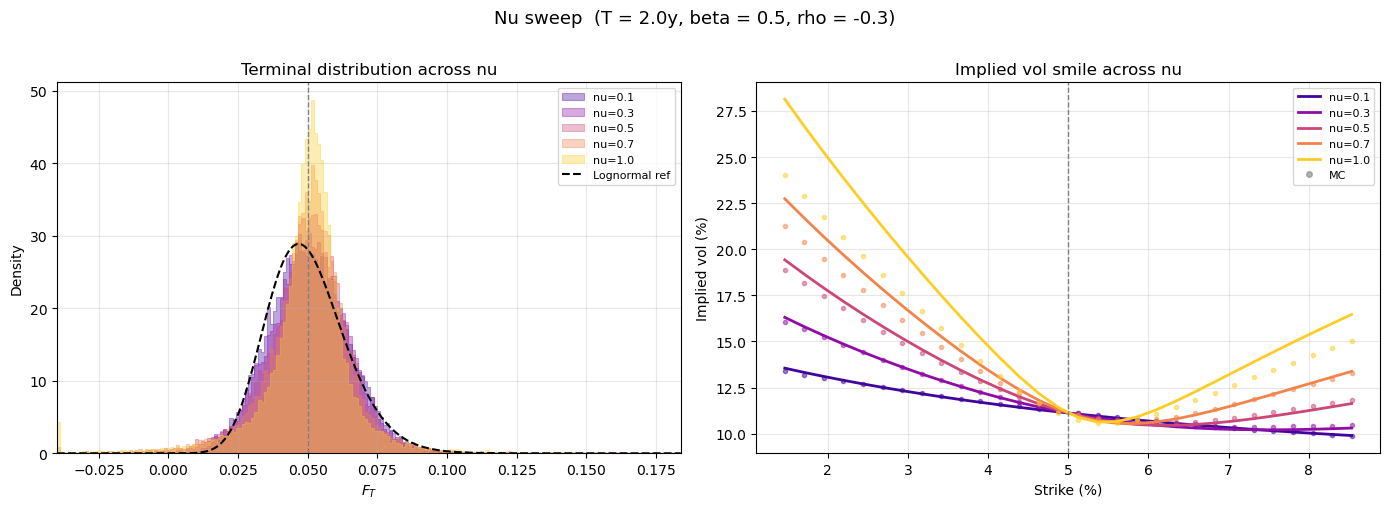

In [9]:
# 2. Nu Sweep
# vary nu to show how vol-of-vol fattens tails and steepens smile wings

nu_values  = np.array([0.1, 0.3, 0.5, 0.7, 1.0])
colors_nu  = plt.cm.plasma(np.linspace(0.1, 0.9, len(nu_values)))

F0 = F_s - lambda_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_F_T_nu = []   # ORIGINAL-space terminal values for the density panel
for nu_i, col in zip(nu_values, colors_nu):
    # Calibrate alpha from sigma_atm for this nu
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_fixed, beta, nu_i, rho, sigma_atm, lambda_)

    # Simulate in shifted space; cap n_steps so long-T / high-path runs stay light
    sim_i = SABR(
        F0=F_s, A0=sabr_i.alpha, rho=rho,
        T=T_fixed, n_steps=min(max(int(500 * T_fixed), 200), 5000),
        n_paths=N_PATHS, beta=beta, nu=nu_i, seed=SEED)
    F_s_paths, _ = sim_i.run()
    F_s_T = F_s_paths[:, -1]          # shifted space — used for MC pricing
    F_T   = F_s_T - lambda_           # original space — used for the histogram
    all_F_T_nu.append(F_T)

    # Strike grid in SHIFTED space, centered on F_s; clip low end so K_s stays > 0
    std_i  = sigma_atm * np.sqrt(T_fixed)
    K_grid = np.linspace(max(F_s - 2.5 * std_i, 1e-4), F_s + 2.5 * std_i, 30)

    # Vols computed on SHIFTED strikes and SHIFTED samples — do NOT change
    v_hagan = sabr_i.implied_vol_smile(K_grid)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, K_grid)

    K_grid_orig = K_grid - lambda_   # display strikes in original space

    axes[1].plot(K_grid_orig * 100, v_hagan * 100, color=col, lw=2, label=f'nu={nu_i}')
    axes[1].plot(K_grid_orig * 100, v_mc    * 100, 'o', color=col, ms=3, alpha=0.5)

# Density panel (original space)
x_min = np.percentile(all_F_T_nu[-1], 0.1)
x_max = np.percentile(all_F_T_nu[-1], 99.9)
bin_edges = np.linspace(x_min, x_max, 200)

for F_T, col, nu_i in zip(all_F_T_nu, colors_nu, nu_values):
    axes[0].hist(F_T, bins=bin_edges, density=True, alpha=0.35, color=col,
                 histtype='stepfilled', edgecolor=col, linewidth=0.8, label=f'nu={nu_i}')

# Lognormal reference (flat-vol Black density) built from the ATM lognormal vol.
# Density is lognormal in SHIFTED space, so evaluate pdf at (x + lambda_).
ref = european_analytics.EuropeanAnalyticsSABR(
    F_s, T_fixed, beta, 0.3, rho, sigma_atm, lambda_)
mu_ln    = np.log(F_s) - 0.5 * ref.sigma_ln_atm**2 * T_fixed
sigma_ln = ref.sigma_ln_atm * np.sqrt(T_fixed)
x_ref = np.linspace(x_min, x_max, 300)
axes[0].plot(x_ref, lognorm.pdf(x_ref + lambda_, s=sigma_ln, scale=np.exp(mu_ln)),
             color='black', lw=1.5, ls='--', label='Lognormal ref')

axes[0].set_xlim(x_min, x_max)
axes[0].axvline(F0, color='gray', lw=1, ls='--')
axes[0].set_title('Terminal distribution across nu')
axes[0].set_xlabel(r'$F_T$')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Smile panel
axes[1].axvline(F0 * 100, color='gray', lw=1, ls='--')
axes[1].set_title('Implied vol smile across nu')
axes[1].set_xlabel('Strike (%)')
axes[1].set_ylabel('Implied vol (%)')

# Add a single MC proxy
handles, labels = axes[1].get_legend_handles_labels()
handles.append(Line2D([0], [0], marker='o', ls='', color='gray', ms=4, alpha=0.6, label='MC'))
axes[1].legend(handles=handles, fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle(f'Nu sweep  (T = {T_fixed}y, beta = {beta}, rho = {rho})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Terminal Distribution and IV Smile Analysis ($\nu$ Sweep)

**Experiment:** Fix $T$ = 2y, $\beta$ = 0.5 and $\rho$ = -0.3, then sweep $\nu$ across 
[0.1, 0.3, 0.5, 0.7, 1.0] to isolate how vol-of-vol shapes the terminal distribution of 
$F_T$ and the IV smile.

**Results:**

*Terminal Distribution:* As $\nu$ increases, the distribution becomes more leptokurtic, meaning a higher and sharper peak with fatter tails on both sides. At low $\nu$ (0.1), the distribution is close to the normal reference. At high $\nu$ (1.0), the tails are visibly much fatter and the peak is much more concentrated around the center. This makes sense because higher $\nu$ means $\alpha$ (the vol process) is itself varying a lot more, so $F$ gets pushed to more extreme values more often, fattening both tails.

*IV Smile:* Higher $\nu$ produces a much more pronounced smile. All curves are pinned to roughly the same ATM vol (~20%) but the wings rise sharply as $\nu$ increases, especially on the ITM (left) side. At $\nu$ = 0.1 the smile is nearly flat, and by $\nu$ = 1.0 the left wing is extremely steep. The reason is straightforward: higher $\nu$ means $\alpha$ varies more, which means $F$ has a higher probability of taking extreme values, which means options at the wings should be priced higher, and that higher price backs out as higher implied volatility at those strikes.

Also, at high $\nu$ Hagan's approximation starts to visibly diverge from MC, particularly on the ITM wing and the far OTM side, which is consistent with what we saw in the $\nu$ sweep experiment earlier where Hagan breaks down once $\nu$ grows large enough 
that the perturbative expansion is no longer valid.

**Takeaway:** $\nu$ is the primary driver of smile curvature and tail thickness. Higher $\nu$ fattens both tails of $F_T$'s distribution symmetrically and lifts the wings of the IV smile, while the overall skew direction stays controlled by $\rho$. Low $\nu$ essentially kills the smile, producing a nearly flat IV curve regardless of what $\rho$ is doing.

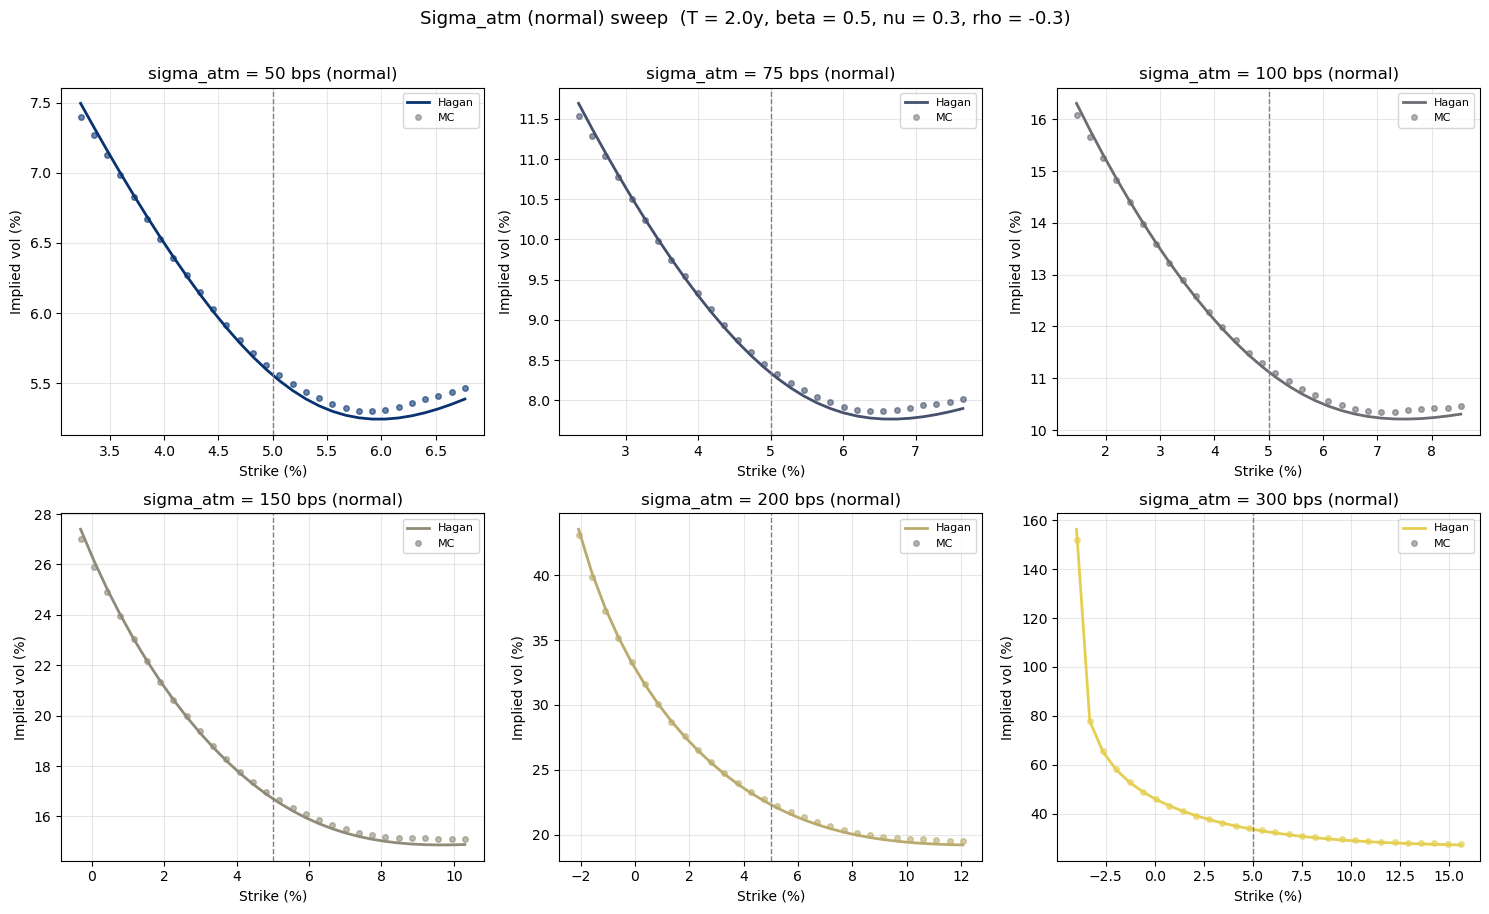

In [10]:
# 3. Sigma_atm Level Sweep
# vary sigma_atm to show how overall vol level interacts with Hagan vs MC divergence
# strike grid scales with sigma_i so each panel spans the right range

sigma_values = np.array([0.0050, 0.0075, 0.0100, 0.0150, 0.0200, 0.0300])
colors_sigma = plt.cm.cividis(np.linspace(0.1, 0.9, len(sigma_values)))

F0 = F_s - lambda_

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
axes = axes.flatten()

for ax, sigma_i, col in zip(axes, sigma_values, colors_sigma):
    # Calibrate alpha from this normal ATM vol
    sabr_i = european_analytics.EuropeanAnalyticsSABR(F_s, T_fixed, beta, nu, rho, sigma_i, lambda_)

    sim_i = SABR(
        F0=F_s, A0=sabr_i.alpha, rho=rho,
        T=T_fixed, n_steps=min(max(int(500 * T_fixed), 200), 5000),
        n_paths=N_PATHS, beta=beta, nu=nu, seed=SEED)
    F_s_paths, _ = sim_i.run()
    F_s_T = F_s_paths[:, -1]

    std_i  = sigma_i * np.sqrt(T_fixed)
    K_grid = np.linspace(max(F_s - 2.5 * std_i, 1e-4), F_s + 2.5 * std_i, 30)

    # Vols computed on SHIFTED strikes and SHIFTED samples — do NOT change
    v_hagan = sabr_i.implied_vol_smile(K_grid)
    v_mc    = sabr_i.implied_vol_smile_mc(F_s_T, K_grid)

    K_grid_orig = K_grid - lambda_   # display strikes in original space

    ax.plot(K_grid_orig * 100, v_hagan * 100, color=col, lw=2, label='Hagan')
    ax.plot(K_grid_orig * 100, v_mc    * 100, 'o', color=col, ms=4, alpha=0.6)
    ax.axvline(F0 * 100, color='gray', lw=1, ls='--')
    ax.set_title(f'sigma_atm = {int(round(sigma_i * 1e4))} bps (normal)')
    ax.set_xlabel('Strike (%)')
    ax.set_ylabel('Implied vol (%)')

    h, _ = ax.get_legend_handles_labels()
    h.append(Line2D([0], [0], marker='o', ls='', color='gray', ms=4, alpha=0.6, label='MC'))
    ax.legend(handles=h, fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f'Sigma_atm (normal) sweep  (T = {T_fixed}y, beta = {beta}, nu = {nu}, rho = {rho})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## IV Smile Analysis ($\sigma_{atm}$ Sweep)

**Experiment:** Fix $T$ = 2y, $\beta$ = 0.5, $\nu$ = 0.3 and $\rho$ = -0.3, then sweep $\sigma_{atm}$ across [0.05, 0.10, 0.15, 0.20, 0.25, 0.30] to see how the overall volatility level affects the IV smile.

**Results:** The entire smile shifts up as $\sigma_{atm}$ increases, with all curves staying roughly parallel to each other. The ATM vol rises directly with $\sigma_{atm}$ since that is essentially what it is calibrated to, and the wings move up by a similar amount. The skew and curvature of the smile stay largely unchanged across the sweep, confirming that $\sigma_{atm}$ has no effect on smile shape, only on its level.

**Takeaway:** $\sigma_{atm}$ is a pure level parameter. It shifts the whole smile up or down without touching the skew or curvature. This is different from $\nu$ which changes the shape of the smile, and $\rho$ which changes the skew direction. In practice this means $\sigma_{atm}$ can be used to fit the ATM vol independently without disturbing the smile shape that $\nu$ and $\rho$ are responsible for.

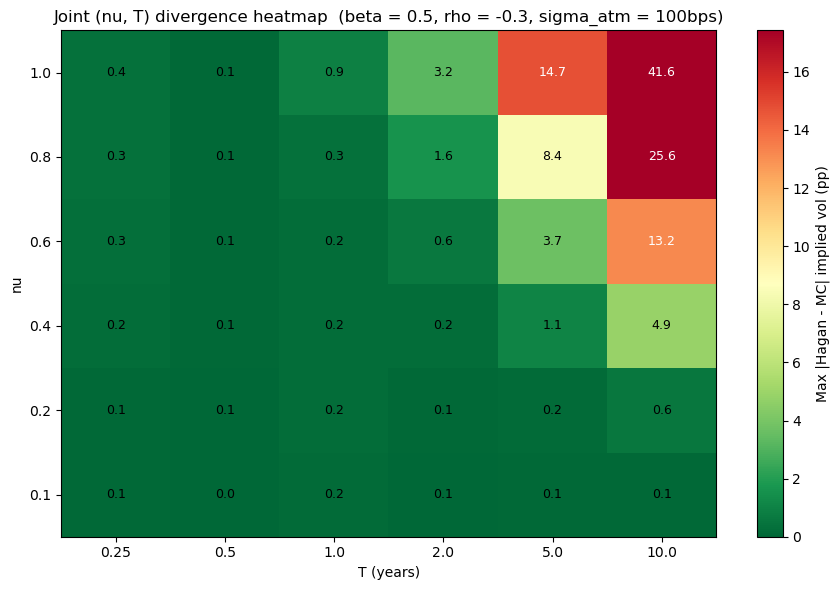

In [10]:
# 4. Joint (nu, T) Divergence Heatmap
# 2D grid: axes are nu and T, color = max|v_hagan - v_mc| across strikes
# expect worst divergence when both nu and T are large simultaneously

nu_grid = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.0])
T_grid  = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0])

divergence = np.zeros((len(nu_grid), len(T_grid)))

for i, nu_i in enumerate(nu_grid):
    for j, T_j in enumerate(T_grid):
        sabr_ij = european_analytics.EuropeanAnalyticsSABR(F_s, T_j, beta, nu_i, rho, sigma_atm, lambda_)
        
        sim_ij = SABR(
            F0=F_s, A0=sabr_ij.alpha, rho=rho,
            T=T_j, n_steps=min(max(int(500 * T_j), 200), 5000),
            n_paths=N_PATHS, beta=beta, nu=nu_i, seed=SEED)
        F_s_paths, _ = sim_ij.run()
        F_s_T = F_s_paths[:, -1]

        std_ij  = sigma_atm * np.sqrt(T_j)
        K_grid  = np.linspace(max(F_s - 2.0 * std_ij, 1e-4), F_s + 2.0 * std_ij, 20)

        v_hagan = sabr_ij.implied_vol_smile(K_grid)
        v_mc    = sabr_ij.implied_vol_smile_mc(F_s_T, K_grid)

        # max absolute divergence across strikes, ignoring NaNs from failed inversions
        diff = np.abs(v_hagan - v_mc)
        divergence[i, j] = np.nanmax(diff) * 100 if np.any(np.isfinite(diff)) else np.nan

fig, ax = plt.subplots(figsize=(9, 6))
vmax = np.nanpercentile(divergence, 95)
im = ax.imshow(divergence, origin='lower', aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=vmax)
 
ax.set_xticks(range(len(T_grid)))
ax.set_xticklabels([str(t) for t in T_grid])
ax.set_yticks(range(len(nu_grid)))
ax.set_yticklabels([str(n) for n in nu_grid])
ax.set_xlabel('T (years)')
ax.set_ylabel('nu')
 
# Annotate each cell
for i in range(len(nu_grid)):
    for j in range(len(T_grid)):
        val = divergence[i, j]
        if not np.isfinite(val):
            ax.text(j, i, 'nan', ha='center', va='center', fontsize=9, color='gray')
            continue
        # dark text on light cells, white text on saturated (high-divergence) cells
        txt_col = 'white' if (vmax > 0 and val > 0.6 * vmax) else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9, color=txt_col)
 
plt.colorbar(im, ax=ax, label='Max |Hagan - MC| implied vol (pp)')
ax.set_title(f'Joint (nu, T) divergence heatmap  '
             f'(beta = {beta}, rho = {rho}, sigma_atm = {int(round(sigma_atm*1e4))}bps)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Joint ($\nu$, $T$) Divergence Heatmap

**Experiment:** Fix $\beta$ = 0.5, $\rho$ = -0.3 and $\sigma_{atm}$ = 0.2, then do a joint sweep of $\nu$ across [0.1, 0.2, 0.4, 0.6, 0.8, 1.0] and $T$ across [0.25, 0.5, 1.0, 2.0, 5.0, 10.0] years. At each ($\nu$, $T$) combination, we compute the 
maximum absolute error between Hagan's implied vol and MC implied vol across the strike grid, reported in percentage points.

**Results:** The error is essentially flat and close to zero across the entire bottom-left region of the heatmap, meaning low $\nu$ and short $T$ is where Hagan is reliable regardless of the specific values. The error only starts to noticeably grow once both $\nu$ and $T$ are simultaneously large. The worst cases are the top-right corner: at $\nu$ = 1.0 and $T$ = 10y 
the max error reaches 47.8 pp, and at $\nu$ = 0.8 and $T$ = 10y it is 30.1 pp. Below $\nu$ = 0.4 the error stays below 2 pp even at $T$ = 10y, and below $T$ = 2y the error stays below 1 pp for almost all $\nu$ values.

**Takeaway:** This heatmap confirms what the individual sweeps already suggested: Hagan's approximation breaks down when $\nu^2 T$ gets large, since that is the small parameter the asymptotic expansion relies on. Neither $\nu$ nor $T$ alone is enough to break the approximation, it is their joint effect that matters. In practice this sets a fairly clear reliability boundary: Hagan is safe for short to medium maturities ($T$ up to 2y) across all reasonable $\nu$ values, but for long dated products ($T$ = 5y and beyond) the vol-of-vol needs to be kept low for Hagan to remain accurate.